# Procedimiento de cálculo de los umbrales para máscara de los 3 cubos de test.

# 0. Importaciones y Configuración

## 0.1. Importaciones

In [1]:
from astropy.io import fits
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq
from astropy.modeling.models import SmoothlyBrokenPowerLaw1D
from astropy.modeling.fitting import LevMarLSQFitter
import os
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
import sys
import astropy.constants as const

sys.path.append('../../src')

DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data'

## 0.2. Configuración

In [2]:
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 12,
    "figure.figsize": (3.5, 2.625), # 4:3 ratio for single-column
    "savefig.dpi": 600
})

## 0.3. Definción de funciones

In [3]:
def estimar_s(counts_pos, counts_neg, edges, ventana):
    """
    Ajuste de mínimos cuadrados ponderado del factor de escala s
    tal que counts_pos ~ s * counts_neg en la ventana de bajo flujo.

    ventana: (flujo_min, flujo_max) - rango dominado por ruido residual
    """
    centers = np.sqrt(edges[:-1] * edges[1:])  # centro geométrico (bins log)
    mask = (centers >= ventana[0]) & (centers <= ventana[1])

    Np = counts_pos[mask].astype(float)
    Nn = counts_neg[mask].astype(float)

    # descartar bins vacíos en el negativo (no aportan y rompen los pesos)
    ok = Nn > 0
    Np, Nn = Np[ok], Nn[ok]

    # iteración: s aparece en su propia varianza
    s = np.sum(Nn * Np) / np.sum(Nn**2)   # inicialización sin pesos
    for _ in range(10):
        var = Np + s**2 * Nn              # varianza poissoniana de la diferencia
        var = np.where(var > 0, var, 1.0) # guarda contra division por cero
        w = 1.0 / var
        s_new = np.sum(w * Nn * Np) / np.sum(w * Nn**2)
        if abs(s_new - s) < 1e-10:
            s = s_new
            break
        s = s_new

    sigma_s = np.sqrt(1.0 / np.sum(w * Nn**2))

    # chi2 reducido como diagnóstico de bondad de ajuste
    resid = Np - s * Nn
    chi2 = np.sum(resid**2 / var)
    dof = len(Np) - 1
    chi2_red = chi2 / dof if dof > 0 else np.nan

    return s, sigma_s, chi2_red



In [4]:
def broken_power_law(x, A1, B1, B2, x_break):
    """Power law quebrada con continuidad en x_break"""
    y = np.where(
        x < x_break,
        A1 * (x / x_break)**B1,
        A1 * (x / x_break)**B2
    )
    return y

In [5]:
def estimacion_s_y_xbreak(counts_pos, counts_neg, bin_edges_pos, bin_center_neg, flux_neg):

    # - 1° iteración s - #
    s, sigma_s, chi2_red = estimar_s(counts_pos, counts_neg, bin_edges_pos,
                                    ventana=(0.0, np.max(flux_neg)))

    counts_neg_scaled = counts_neg * s

    counts_pos_mod = counts_pos.copy()
    counts_pos_mod[counts_pos_mod == 0] = 1

    counts_neg_mod = counts_neg_scaled.copy()
    counts_neg_mod[counts_neg_mod == 0] = 1

    div_counts = counts_pos_mod / counts_neg_mod

    # - 1° iteración x_break - #
    excess = counts_pos - counts_neg_scaled
    err    = np.sqrt(counts_pos + counts_neg_scaled)
    idx    = np.argmax((excess > 3 * err) & (bin_center_neg > 0))
    x_break_0 = bin_center_neg[idx]

    mask_high = bin_center_neg > x_break_0

    B2_0 = np.polyfit(np.log10(bin_center_neg[mask_high]),
                    np.log10(div_counts[mask_high]), 1)[0] if mask_high.sum() > 2 else 2.0

    p0 = [1.0, 0.0, B2_0, x_break_0]

    # - 1° iteración ajuste - #
    print(f"Primer estimación: s = {s:.4f} ± {sigma_s:.4f}   (chi2_red = {chi2_red:.2f})")
    popt, pcov = curve_fit(
        broken_power_law,
        bin_center_neg,
        div_counts,
        p0=p0,
        sigma=div_counts,
        maxfev=50000
    )
    print(f"Primer ajuste: x_break = {popt[3]:.2e}")

    # - 2° iteración s - #
    s, sigma_s, chi2_red = estimar_s(counts_pos, counts_neg, bin_edges_pos,
                                    ventana=(0.0, popt[3]))

    counts_neg_scaled = counts_neg * s

    counts_pos_mod = counts_pos.copy()
    counts_pos_mod[counts_pos_mod == 0] = 1
    counts_neg_mod = counts_neg_scaled.copy()
    counts_neg_mod[counts_neg_mod == 0] = 1

    div_counts = counts_pos_mod / counts_neg_mod
    
    # - 2° iteración x_break - #
    excess = counts_pos - counts_neg_scaled
    err    = np.sqrt(counts_pos + counts_neg_scaled)
    idx    = np.argmax((excess > 3 * err) & (bin_center_neg > 0))
    x_break_0 = bin_center_neg[idx]

    mask_high = bin_center_neg > x_break_0

    B2_0 = np.polyfit(np.log10(bin_center_neg[mask_high]),
                    np.log10(div_counts[mask_high]), 1)[0] if mask_high.sum() > 2 else 2.0

    p0 = [1.0, 0.0, B2_0, x_break_0]

    # - 2° iteración ajuste - #
    print(f"Segunda estimación: s = {s:.4f} ± {sigma_s:.4f}   (chi2_red = {chi2_red:.2f})")
    popt, pcov = curve_fit(
        broken_power_law,
        bin_center_neg,
        div_counts,
        p0=p0,
        sigma=div_counts,
        maxfev=50000
    )
    print(f"Segundo ajuste: x_break = {popt[3]:.2e}")
    return s, popt

In [6]:
def umbral(cube_name, cube_type_dir, cube_dir, n_bins=200, denoised=False, threshold=5):
    """
    Procedimiento de cálculo del umbral de un cubo.
    """
    ### --- APERTURA --- ###
    if not denoised:
        hdu = fits.open(os.path.join(DATA_DIR,cube_type_dir,cube_dir, f'{cube_name}.fits'))

    else:
        hdu = fits.open(os.path.join(DATA_DIR,cube_type_dir,cube_dir, f'{cube_name}_wavelets_iterative_soft_{threshold}.fits'))
    
    data_pos = hdu[0].data
    flux_pos = data_pos[
        (np.isfinite(data_pos)) & # Se eliminan los NaN
        (data_pos != 0) # Se eliminan los 0
        ].flatten()

    if denoised:
        hdu = fits.open(os.path.join(DATA_DIR,cube_type_dir,cube_dir, f'{cube_name}_wavelets_iterative_soft_{threshold}_negative.fits'))
        MULTIPLICADOR = 1
    else:
        MULTIPLICADOR = -1

    data_neg = hdu[0].data * MULTIPLICADOR
    flux_neg = data_neg[
        (np.isfinite(data_neg)) & # Se eliminan los NaN
        (data_neg != 0) # Se eliminan los 0
        ].flatten()
    ### --- /APERTURA --- ###

    ### --- BINS --- ###
    # Binning logarítmico: evita la sobrecarga de bins en el flujo bajo.
    # Solo el flujo positivo entra al histograma (los bordes arrancan > 0).
    hi = np.max(flux_neg)
    lo = hi / 1e3  # ~3 décadas; acota la cola diminuta que dejaría bins vacíos
    bins = np.logspace(np.log10(lo), np.log10(hi), n_bins)
    ### --- /BINS --- ###

    ### --- HISTOGRAMA SIN ESCALAMIENTO --- ###
    plt.subplots(figsize=(10, 5))
    counts_pos, bin_edges_pos, _ = plt.hist(
        flux_pos,
        alpha=0.5,
        label='Original cube',
        bins=bins,
        )
    counts_neg, bin_edges_neg, _ = plt.hist(
        flux_neg,
        alpha=0.5,
        label='Negative cube',
        bins=bins,
        )
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('Flujo ($Jy/beam$)')
    plt.ylabel('Número de píxeles ($log(N)$)')
    plt.title(f'Histograma de flujo de {cube_name}')
    plt.legend()
    plt.tight_layout()
    ### --- /HISTOGRAMA SIN ESCALAMIENTO --- ###

    ### --- CENTROS DE LOS BINS --- ###
    bin_center_neg = np.sqrt(bin_edges_neg[:-1] * bin_edges_neg[1:])
    ### --- /CENTROS DE LOS BINS --- ###

    ### --- ESTIMACIÓN DE S Y X_BREAK --- ###
    s, popt = estimacion_s_y_xbreak(counts_pos, counts_neg, bin_edges_pos, bin_center_neg, flux_neg)
    ### --- /ESTIMACIÓN DE S Y X_BREAK --- ###

    ### --- HISTOGRAMA ESCALADO --- ###
    counts_pos, edges = np.histogram(flux_pos, bins=bins)
    counts_neg, _     = np.histogram(flux_neg, bins=bins)
    counts_neg_scaled = counts_neg * s
    centers = 0.5 * (edges[:-1] + edges[1:])
    width = np.diff(edges)
    plt.figure(figsize=(10, 5))
    plt.bar(centers, counts_pos, width=width, align='center',
            color='orange', label='Original cube')
    plt.bar(centers, counts_neg_scaled, width=width, align='center',
            color='skyblue', label=f'Negative cube (scaled {s:.4f})')
    plt.yscale('log')
    plt.xscale('log')
    plt.legend()


    ### --- RAZÓN ENTRE CUENTAS --- ###
    bin_center_neg = np.sqrt(bin_edges_neg[:-1] * bin_edges_neg[1:])
    counts_pos_mod = counts_pos.copy()
    counts_pos_mod[counts_pos_mod == 0] = 1
    counts_neg_mod = counts_neg_scaled.copy()
    counts_neg_mod[counts_neg_mod == 0] = 1
    div_counts = counts_pos_mod / counts_neg_mod
    x_fit = np.logspace(np.log10(bin_center_neg.min()), np.log10(bin_center_neg.max()), n_bins)

    print(f"x_break = {popt[3]:.2e}")
    print(f"B1 (zona plana) = {popt[1]:.3f}")


    ### --- GRÁFICO --- ###
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.scatter(bin_center_neg, div_counts, s=5)

    ax.plot(x_fit, broken_power_law(x_fit, *popt), 'g--', linewidth=1,
            label=f'Power Law: $A={popt[0]:.2e},\\ B={popt[1]:.2e},\\ C={popt[2]:.2e}$')
    plt.xlabel('Flux ($Jy/beam$)')
    plt.ylabel('$N_{pos}/N_{neg}$')
    plt.yscale('log')
    plt.xscale('log')

    return None

# 1. Real Cubes

## 1.1. PointingB

In [7]:
CUBE_TYPE_DIR = 'real_cubes'
CUBE_DIR = 'pointingb'
CUBE_NAME = 'PointingB_calibrated_SourceA_Contsub_CubeLine_Natural_50kms_image_subcube1_subcube'

### 1.1.A. Cubo original

Primer estimación: s = 1.1268 ± 0.0035   (chi2_red = 11.32)
Primer ajuste: x_break = 1.58e-04
Segunda estimación: s = 1.1196 ± 0.0035   (chi2_red = 3.84)
Segundo ajuste: x_break = 1.58e-04
x_break = 1.58e-04
B1 (zona plana) = 0.049


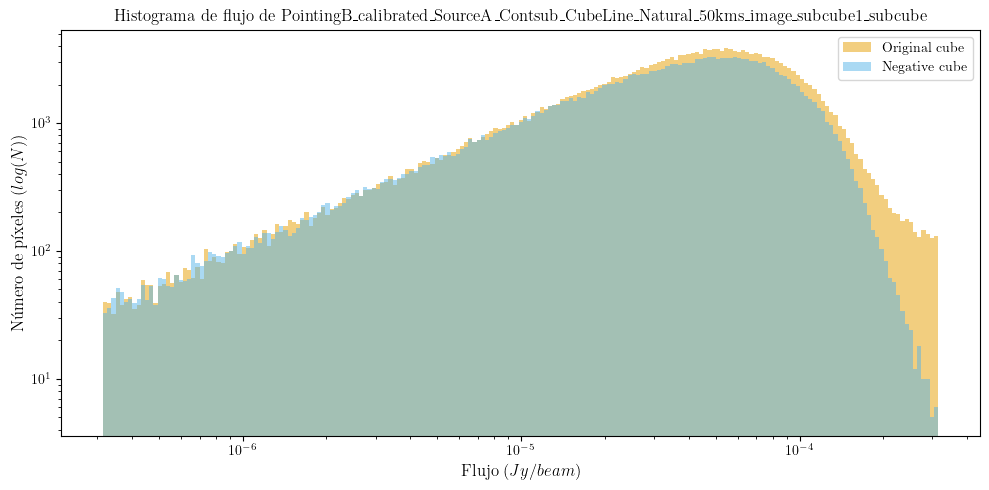

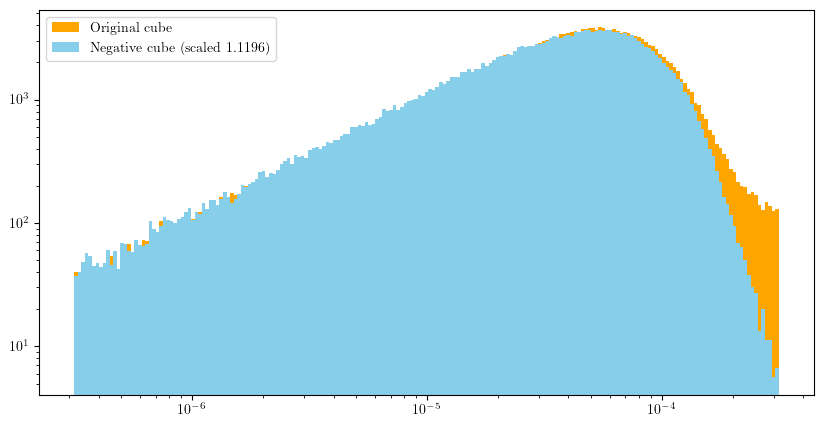

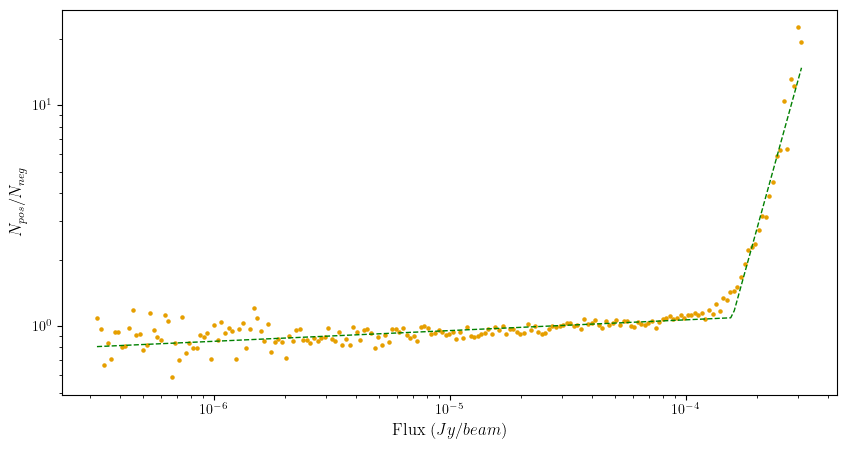

In [8]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=False)

### 1.1.B. Cubo con Denosining por Wavelets

Primer estimación: s = 1.7902 ± 0.0089   (chi2_red = 11.87)
Primer ajuste: x_break = 9.45e-05
Segunda estimación: s = 1.7705 ± 0.0088   (chi2_red = 1.97)
Segundo ajuste: x_break = 9.45e-05
x_break = 9.45e-05
B1 (zona plana) = 0.045


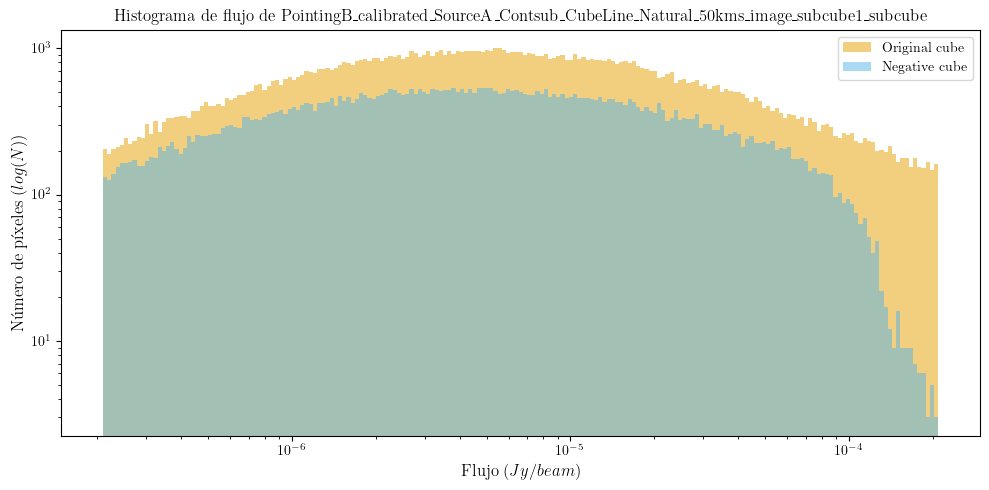

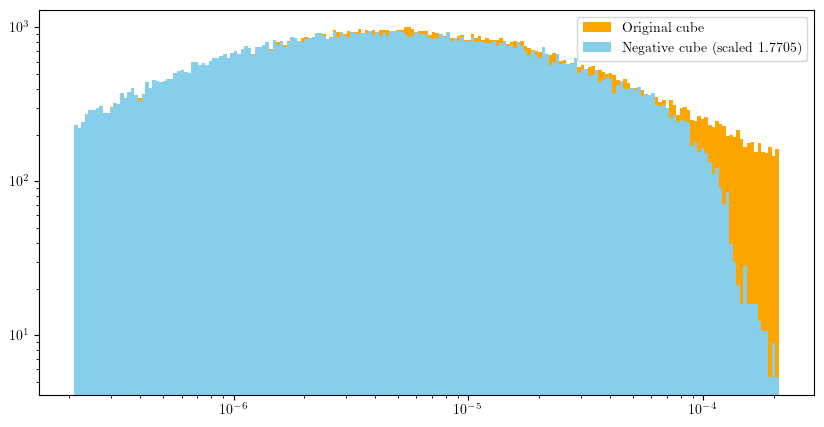

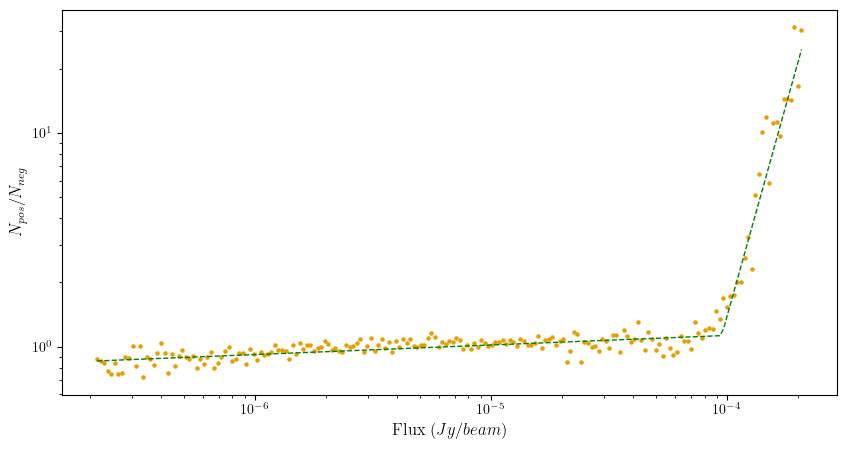

In [23]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=5)

## 1.2. CONDOR01COMB

In [24]:
CUBE_DIR = 'condor01comb'
CUBE_NAME = 'CONDOR01COMB_CO32_15kms_r05._subcube1'

### 1.2.A. Cubo Original

Primer estimación: s = 1.1497 ± 0.0036   (chi2_red = 40.42)
Primer ajuste: x_break = 1.92e-04
Segunda estimación: s = 1.1334 ± 0.0035   (chi2_red = 9.56)
Segundo ajuste: x_break = 1.92e-04
x_break = 1.92e-04
B1 (zona plana) = 0.051


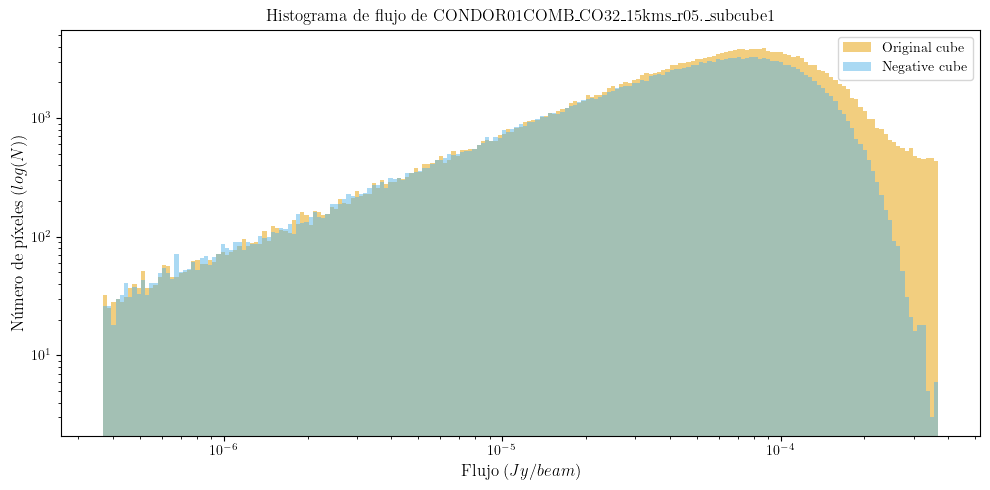

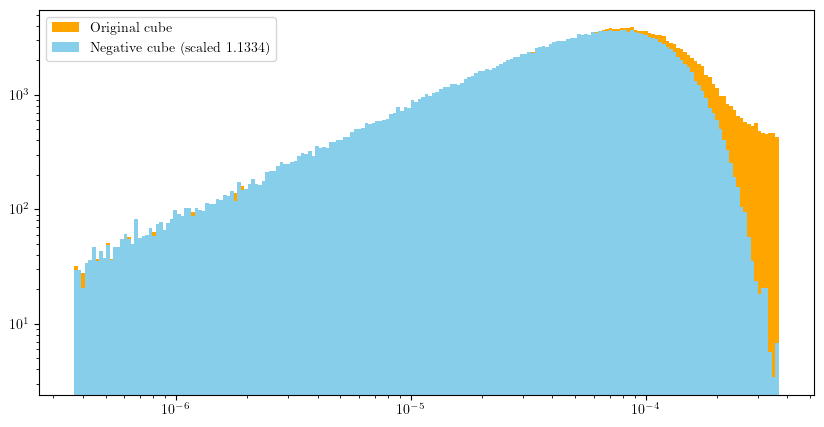

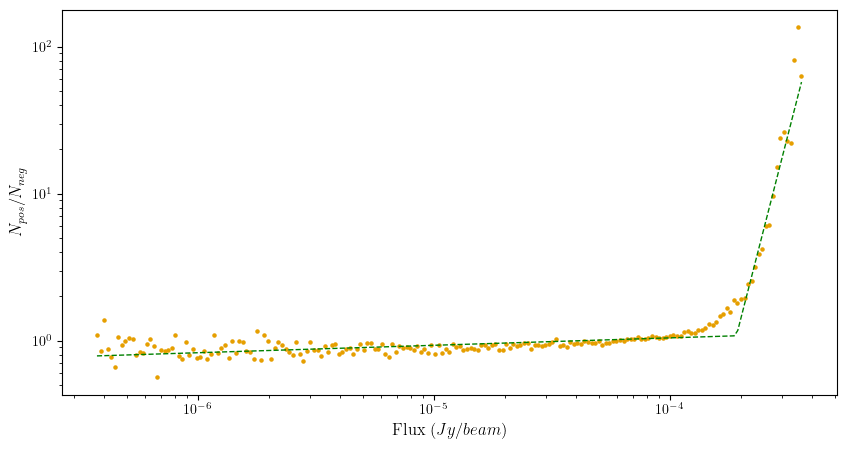

In [25]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=False)

### 1.2.B. Cubo con Denoising por Wavelets

Primer estimación: s = 0.7056 ± 0.0039   (chi2_red = 214.10)
Primer ajuste: x_break = 1.98e-06
Segunda estimación: s = 0.3713 ± 0.0046   (chi2_red = 0.87)
Segundo ajuste: x_break = 1.98e-06
x_break = 1.98e-06
B1 (zona plana) = 0.000


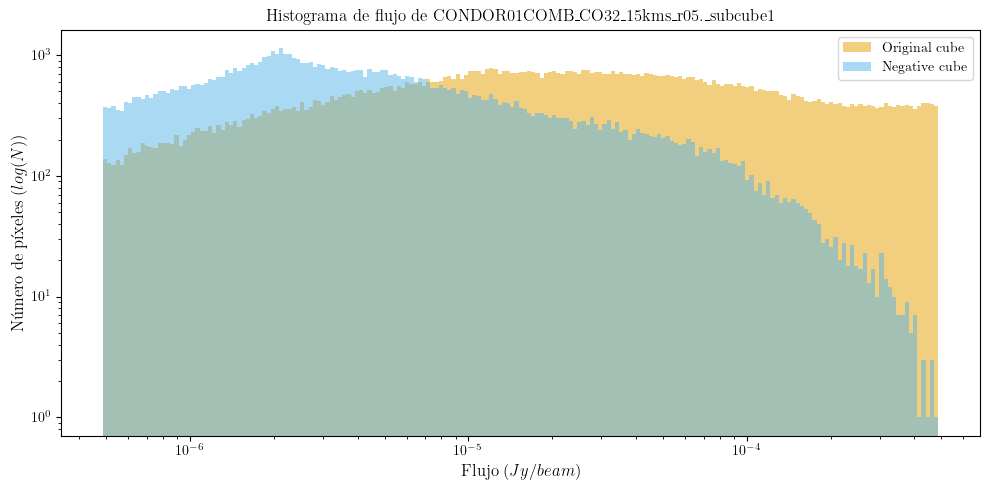

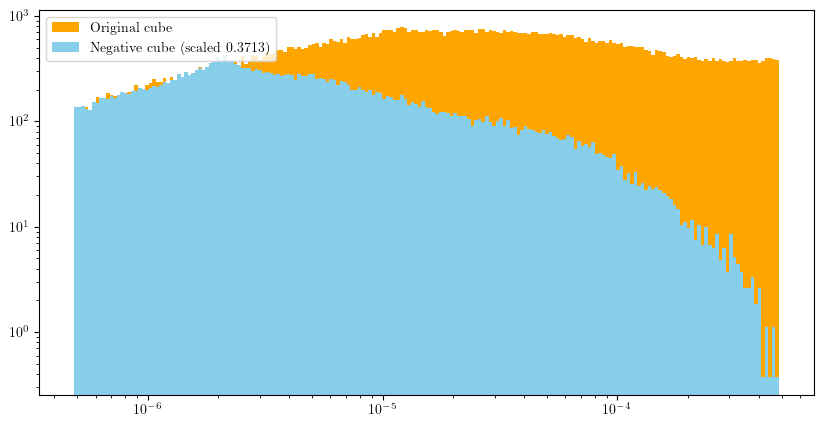

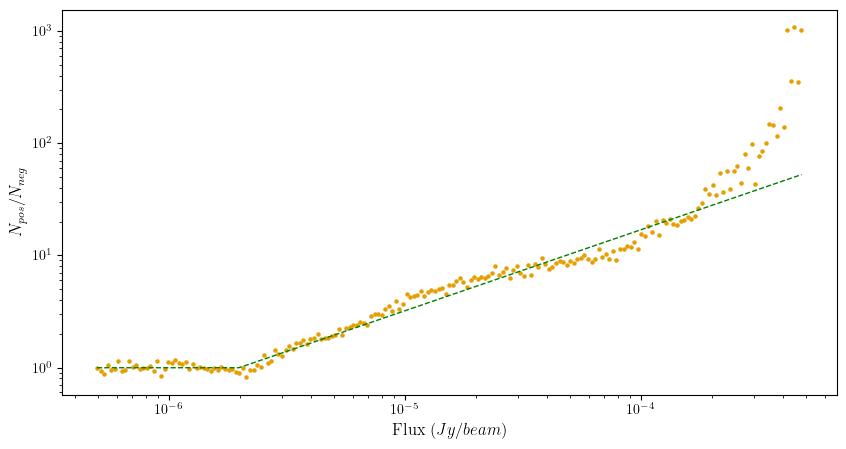

In [27]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=5)

## 1.3. CONDOR06LD

In [34]:
CUBE_DIR = 'condor06ld'
CUBE_NAME = 'CONDOR06LD_spw27_18kms_r05_subcube1'

### 1.3.A. Cubo Original

Primer estimación: s = 1.0138 ± 0.0031   (chi2_red = 3.08)
Primer ajuste: x_break = 4.99e-04
Segunda estimación: s = 1.0130 ± 0.0031   (chi2_red = 1.26)
Segundo ajuste: x_break = 4.99e-04
x_break = 4.99e-04
B1 (zona plana) = 0.012


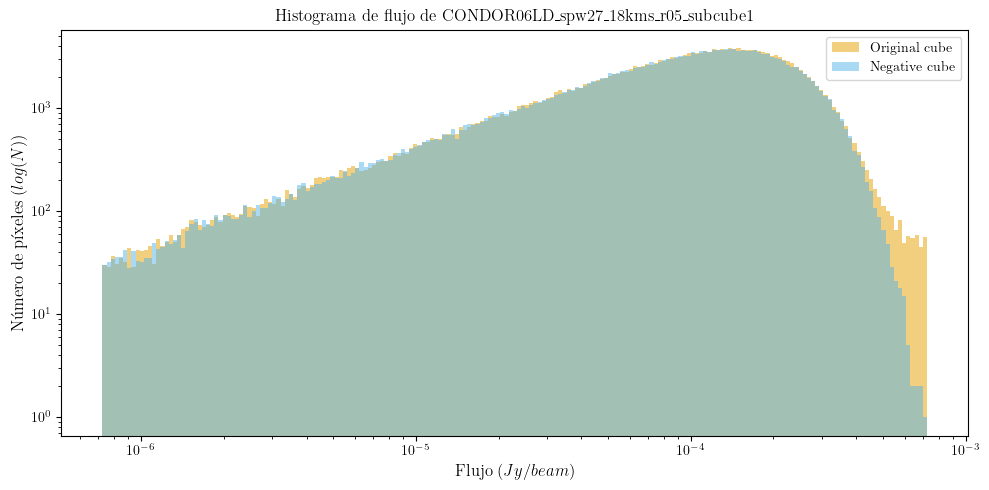

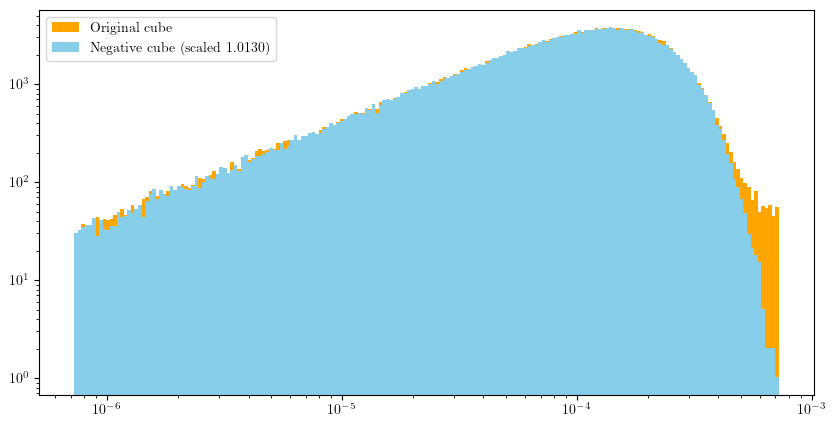

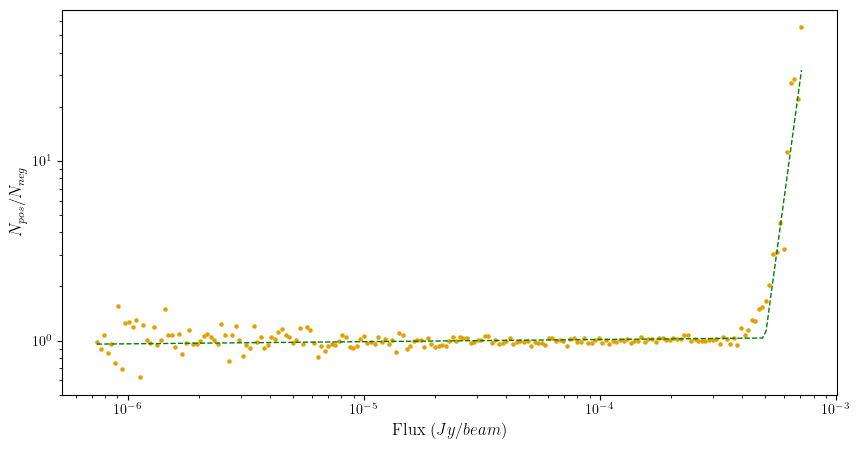

In [29]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=False)

### 1.3.B. Cubo con Denoising por Wavelets

Primer estimación: s = 0.6955 ± 0.0036   (chi2_red = 26.97)
Primer ajuste: x_break = 1.47e-04
Segunda estimación: s = 0.6889 ± 0.0036   (chi2_red = 13.30)
Segundo ajuste: x_break = 1.47e-04
x_break = 1.47e-04
B1 (zona plana) = 0.086


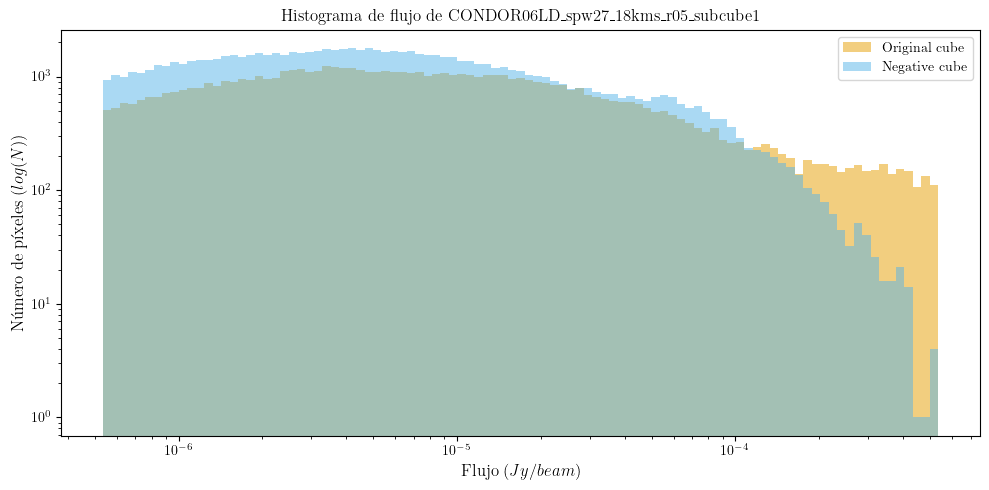

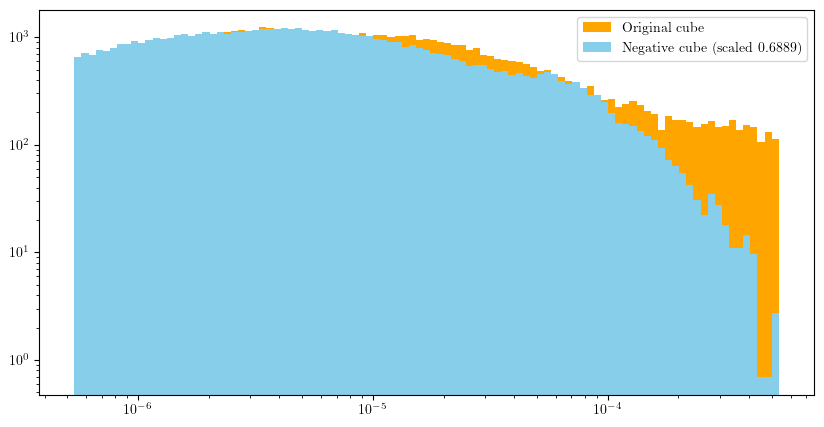

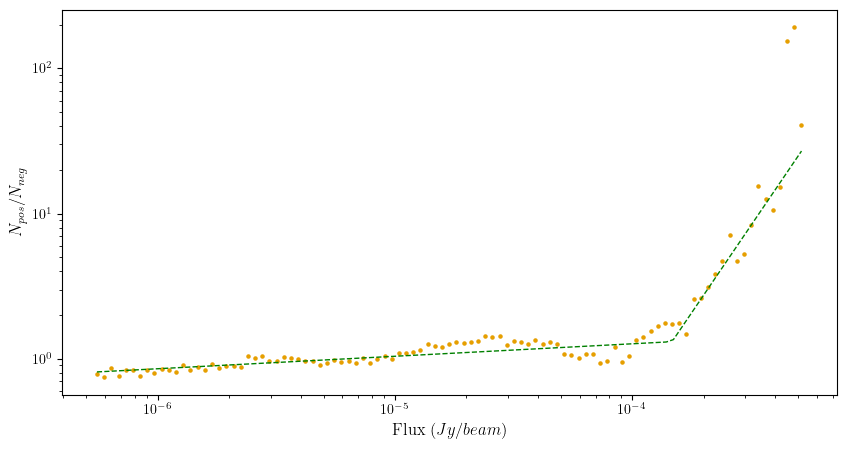

In [43]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=100, denoised=True, threshold=4)

# 2. Mock Cubes

In [88]:
CUBE_TYPE_DIR = 'mock_cubes'

## 2.1. Isolated Galaxy

### 2.1.1. AC5

In [89]:
CUBE_DIR = 'isolated_sub_AC5_N50_width1'
CUBE_NAME = 'isolated_sub_AC5_N50_width1_noisy_sub'

#### 2.1.1.A. Original Cube

Primer estimación: s = 1.1171 ± 0.0012   (chi2_red = 78.78)
Primer ajuste: x_break = 3.56e-04
Segunda estimación: s = 1.1138 ± 0.0012   (chi2_red = 47.84)
Segundo ajuste: x_break = 3.56e-04
x_break = 3.56e-04
B1 (zona plana) = 0.115


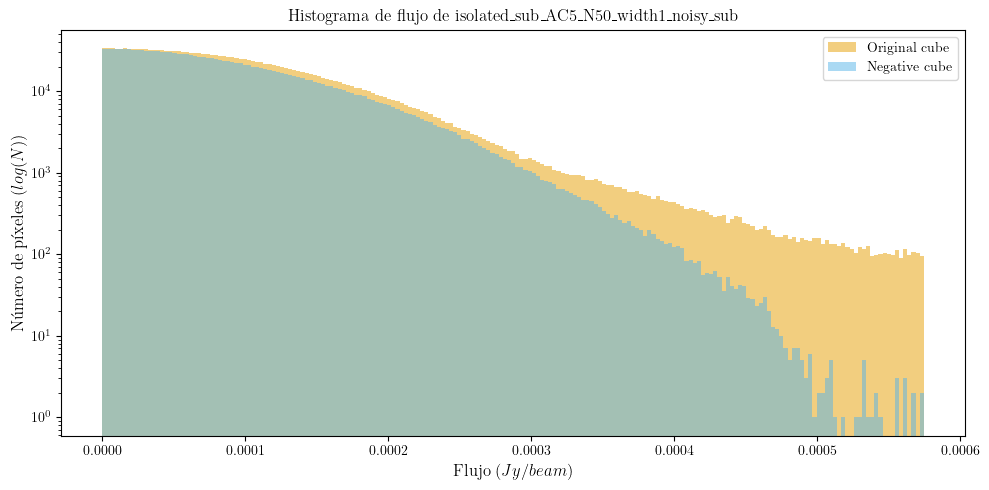

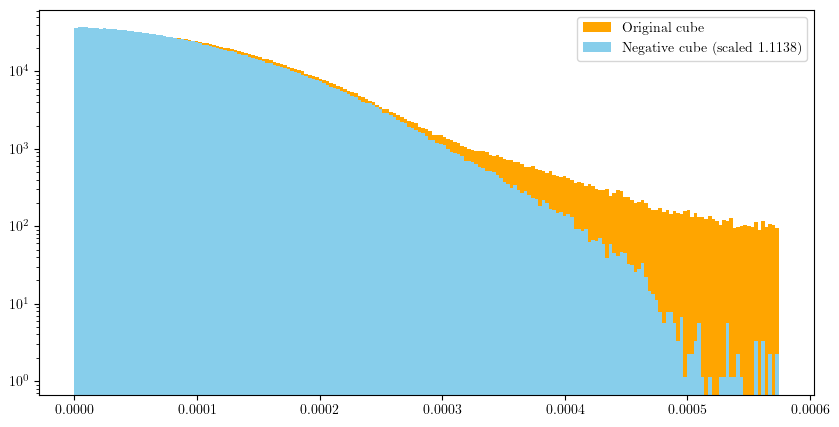

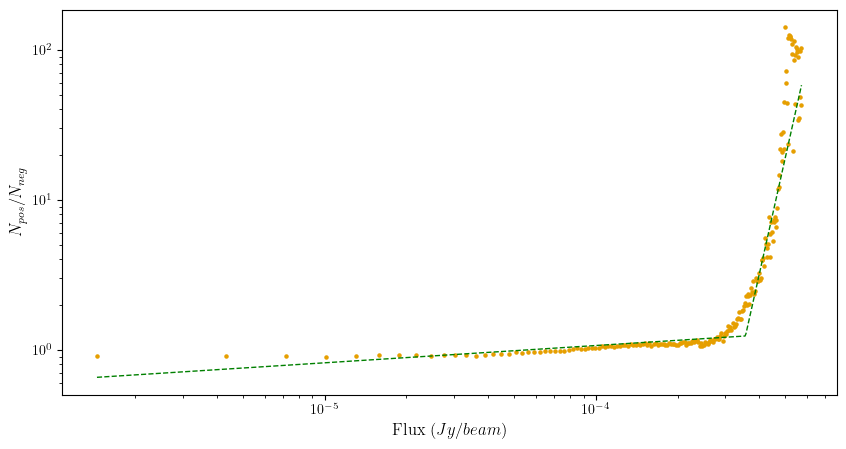

In [90]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=False)

#### 2.1.1.B. Wavelets

Primer estimación: s = 0.9503 ± 0.0018   (chi2_red = 106.83)
Primer ajuste: x_break = 9.55e-05
Segunda estimación: s = 0.9309 ± 0.0018   (chi2_red = 114.57)
Segundo ajuste: x_break = 9.55e-05
x_break = 9.55e-05
B1 (zona plana) = 0.108


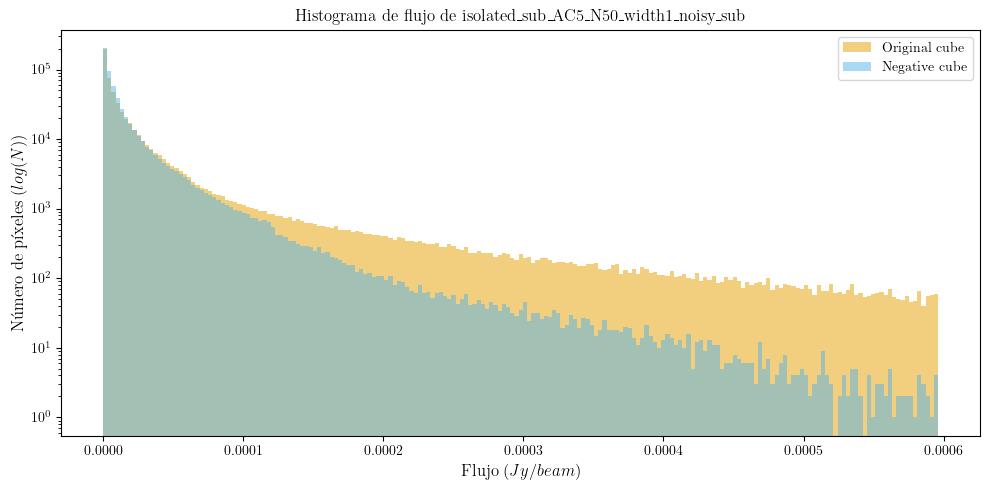

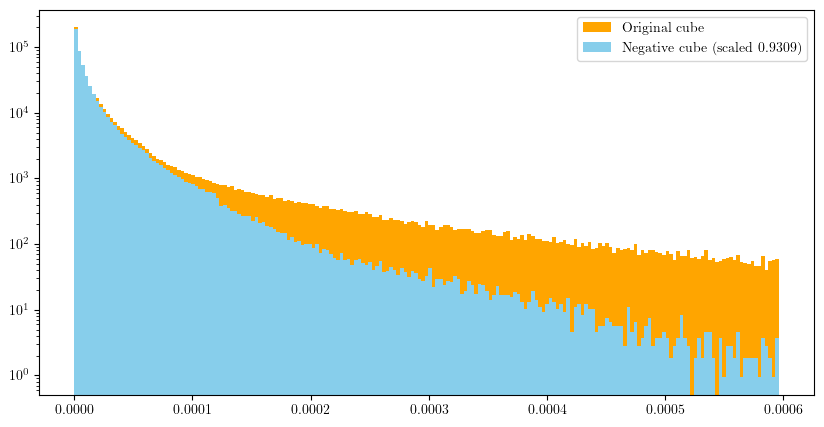

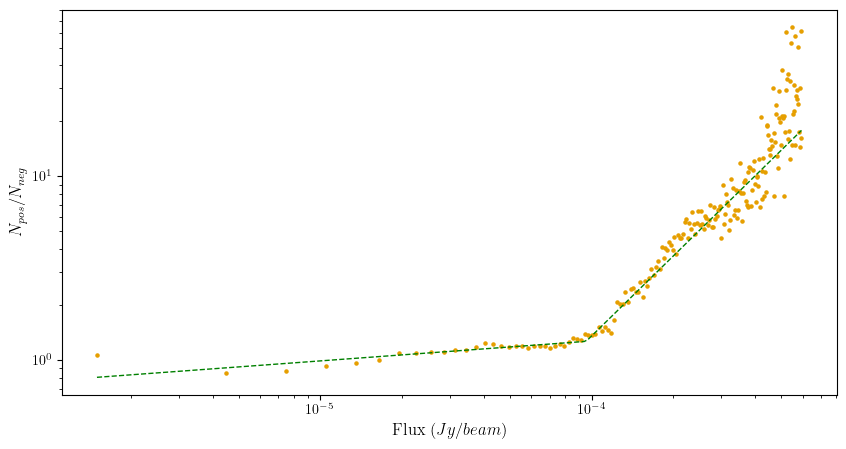

In [91]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=5)

Primer estimación: s = 0.9847 ± 0.0016   (chi2_red = 226.70)
Primer ajuste: x_break = 2.94e-06
Segunda estimación: s = 1.2708 ± 0.0035   (chi2_red = nan)
Segundo ajuste: x_break = 1.11e-04
x_break = 1.11e-04
B1 (zona plana) = 0.268


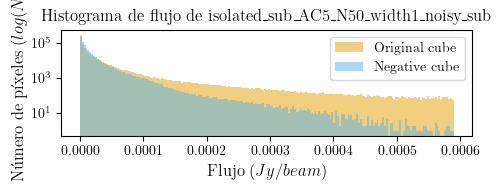

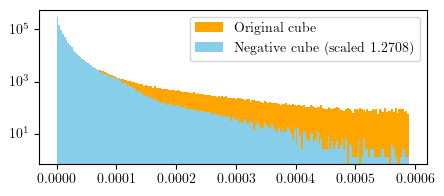

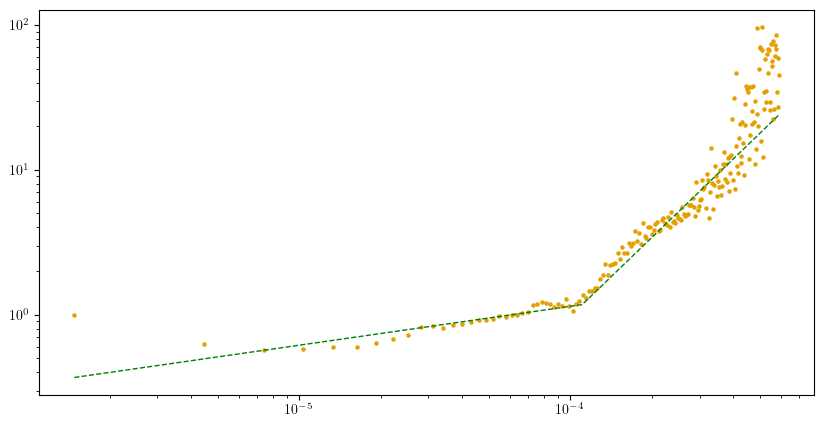

In [35]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=4)

Primer estimación: s = 0.9885 ± 0.0014   (chi2_red = 251.58)
Primer ajuste: x_break = 1.49e-04
Segunda estimación: s = 0.9679 ± 0.0014   (chi2_red = 351.89)
Segundo ajuste: x_break = 1.49e-04
x_break = 1.49e-04
B1 (zona plana) = 0.260


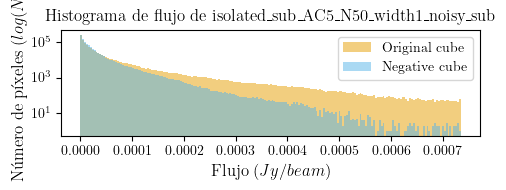

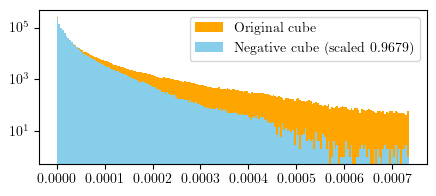

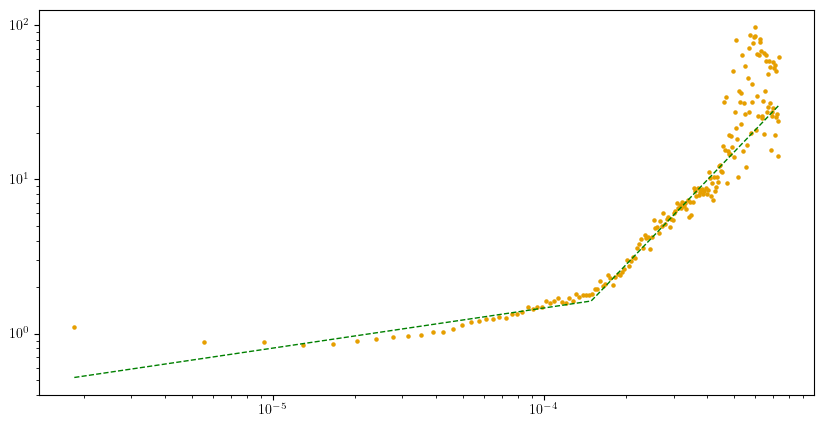

In [36]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=3)

Primer estimación: s = 1.0456 ± 0.0012   (chi2_red = 45.11)
Primer ajuste: x_break = 4.30e-04
Segunda estimación: s = 1.0424 ± 0.0012   (chi2_red = 25.39)
Segundo ajuste: x_break = 4.30e-04
x_break = 4.30e-04
B1 (zona plana) = 0.112


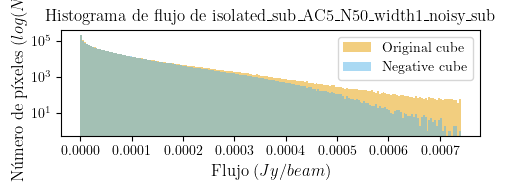

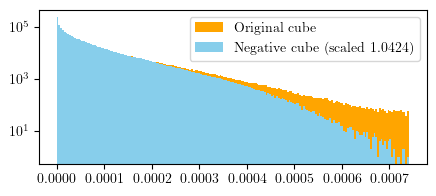

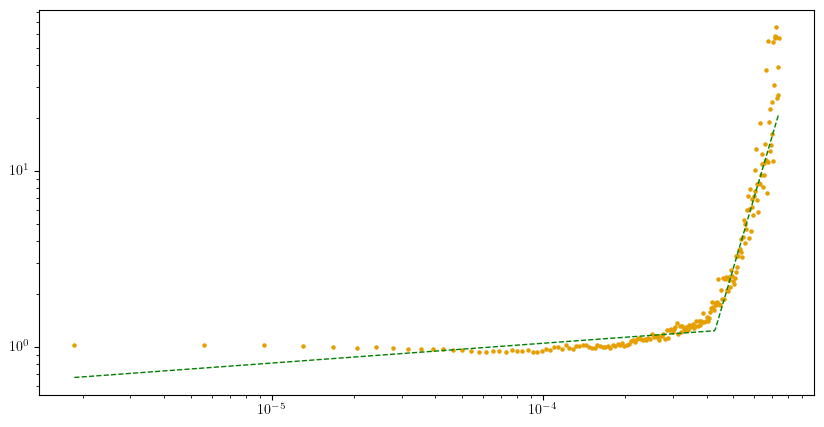

In [15]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=2)

Primer estimación: s = 1.0084 ± 0.0010   (chi2_red = 36.72)
Primer ajuste: x_break = 4.80e-04
Segunda estimación: s = 1.0068 ± 0.0010   (chi2_red = 8.27)
Segundo ajuste: x_break = 4.80e-04
x_break = 4.80e-04
B1 (zona plana) = 0.035


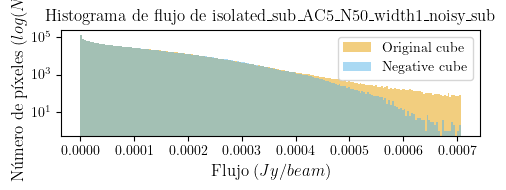

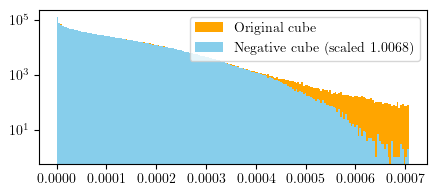

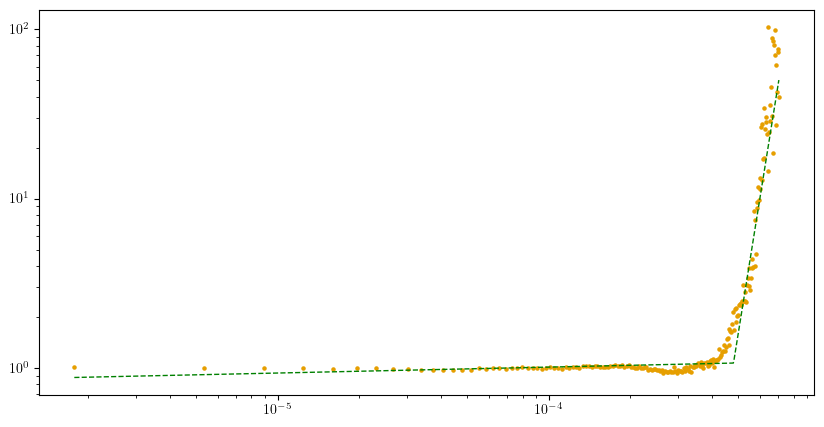

In [37]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=1)

### 2.1.2. AC4

In [47]:
CUBE_DIR = 'isolated_sub_AC4_N50_width1'
CUBE_NAME = 'isolated_sub_AC4_N50_width1_noisy_sub'

#### 2.1.2.A Original Cube

Primer estimación: s = 1.1287 ± 0.0012   (chi2_red = 85.09)
Primer ajuste: x_break = 4.38e-04
Segunda estimación: s = 1.1253 ± 0.0012   (chi2_red = 69.73)
Segundo ajuste: x_break = 4.38e-04
x_break = 4.38e-04
B1 (zona plana) = 0.139


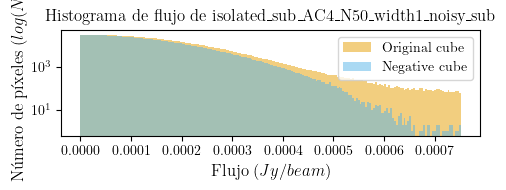

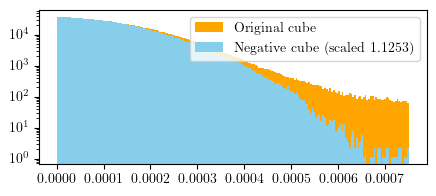

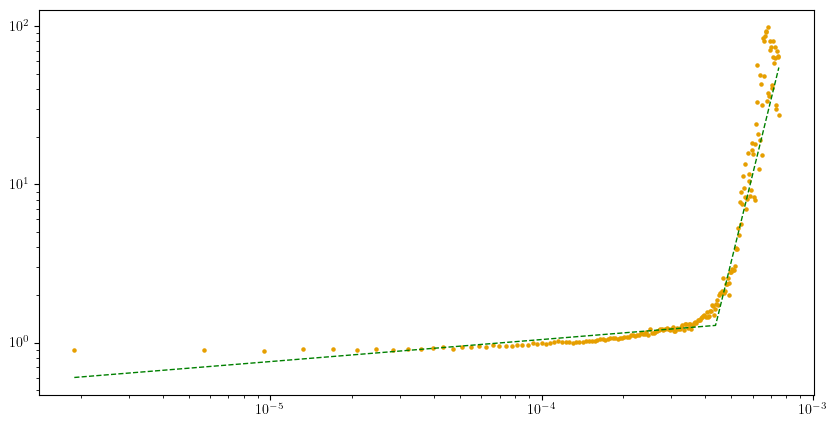

In [48]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=False)

#### 2.1.2.B Wavelets

Primer estimación: s = 1.0243 ± 0.0017   (chi2_red = 380.93)
Primer ajuste: x_break = 1.69e-04
Segunda estimación: s = 1.0110 ± 0.0017   (chi2_red = 1600.93)
Segundo ajuste: x_break = 1.69e-04
x_break = 1.69e-04
B1 (zona plana) = -0.005


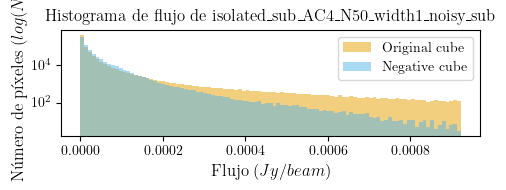

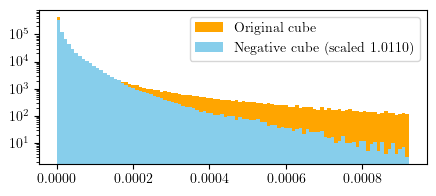

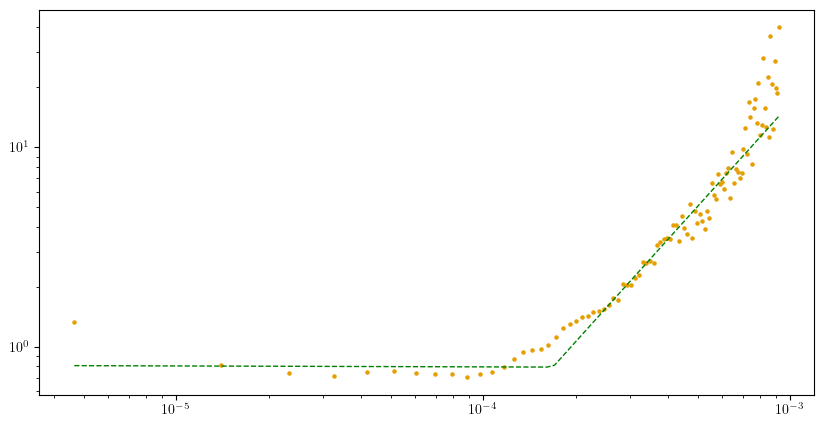

In [46]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=100, denoised=True, threshold=5)

Primer estimación: s = 1.0732 ± 0.0016   (chi2_red = 82.53)
Primer ajuste: x_break = 1.63e-04
Segunda estimación: s = 1.0627 ± 0.0016   (chi2_red = 87.65)
Segundo ajuste: x_break = 1.63e-04
x_break = 1.63e-04
B1 (zona plana) = -0.045


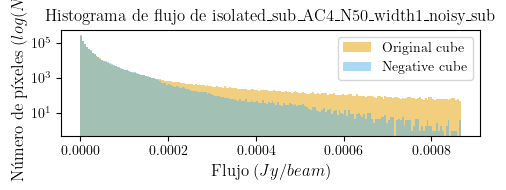

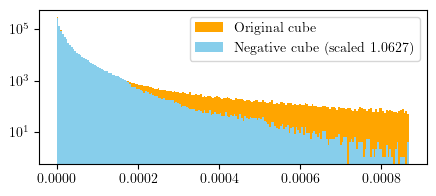

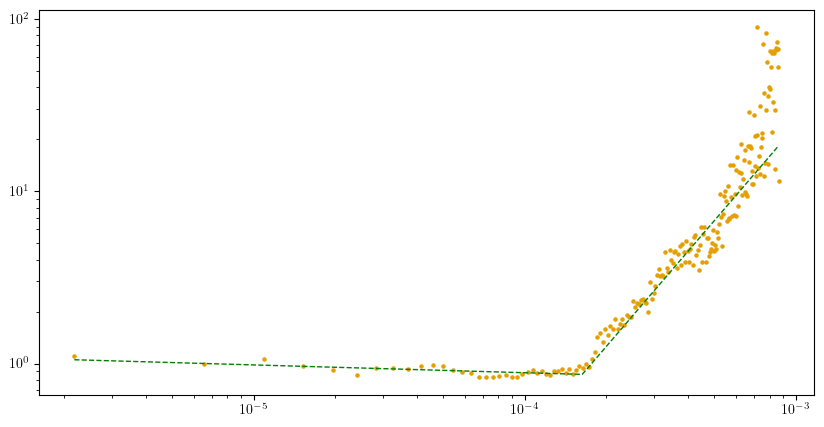

In [41]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=4)

Primer estimación: s = 0.9504 ± 0.0013   (chi2_red = 330.11)
Primer ajuste: x_break = 2.04e-04
Segunda estimación: s = 0.9372 ± 0.0013   (chi2_red = 653.00)
Segundo ajuste: x_break = 2.04e-04
x_break = 2.04e-04
B1 (zona plana) = 0.329


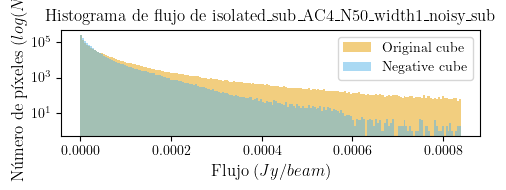

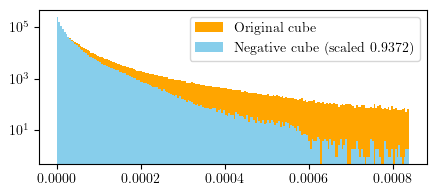

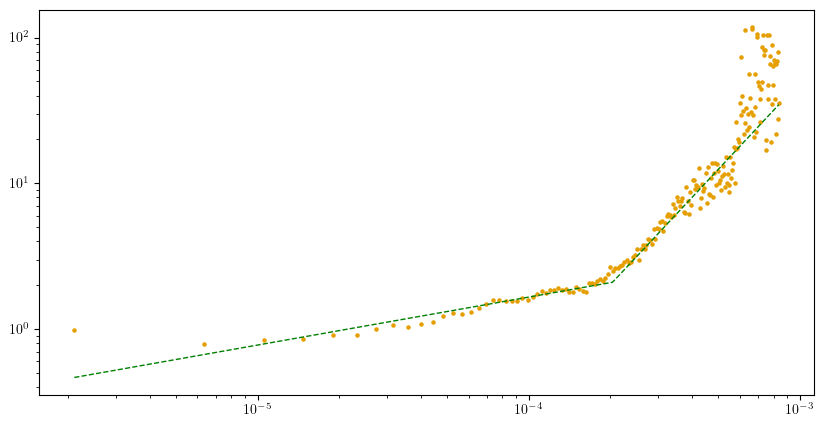

In [42]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=3)

Primer estimación: s = 1.1425 ± 0.0013   (chi2_red = 81.52)
Primer ajuste: x_break = 5.08e-04
Segunda estimación: s = 1.1376 ± 0.0013   (chi2_red = 44.18)
Segundo ajuste: x_break = 5.08e-04
x_break = 5.08e-04
B1 (zona plana) = 0.090


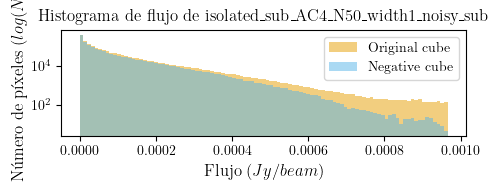

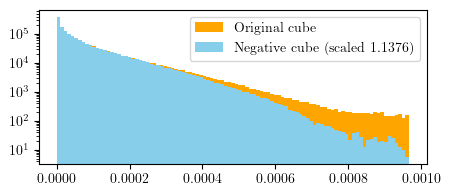

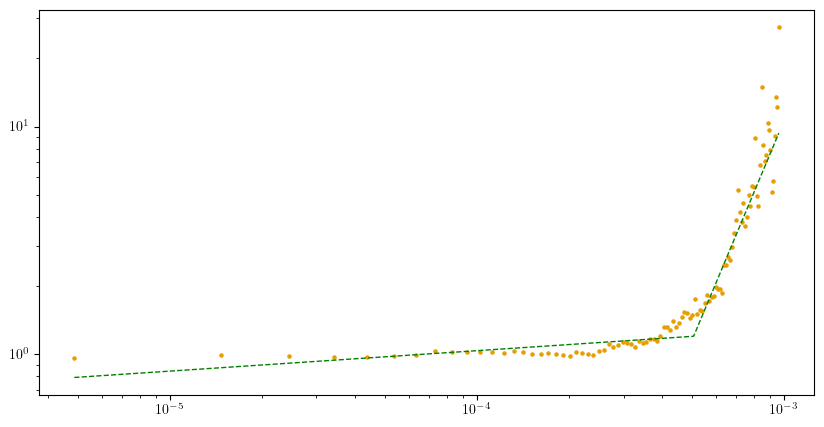

In [49]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=100, denoised=True, threshold=2)

Primer estimación: s = 1.0091 ± 0.0010   (chi2_red = 33.40)
Primer ajuste: x_break = 5.74e-04
Segunda estimación: s = 1.0071 ± 0.0010   (chi2_red = 3.00)
Segundo ajuste: x_break = 5.74e-04
x_break = 5.74e-04
B1 (zona plana) = -0.011


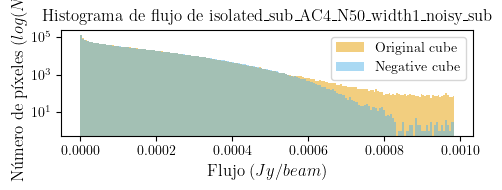

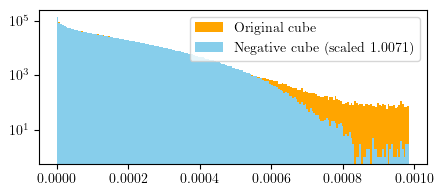

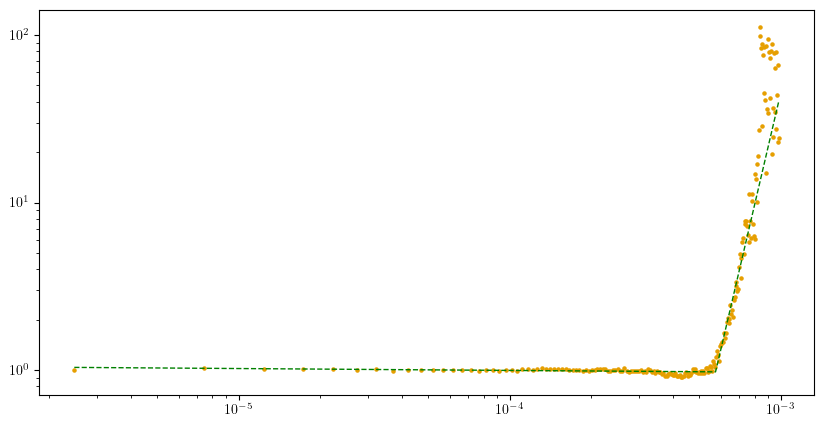

In [44]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=1)

### 2.1.3. AC3

In [50]:
CUBE_DIR = 'isolated_sub_AC3_N50_width1'
CUBE_NAME = 'isolated_sub_AC3_N50_width1_noisy_2_sub'

#### 2.1.3.A Original Cube

Primer estimación: s = 1.0786 ± 0.0012   (chi2_red = 20.18)
Primer ajuste: x_break = 5.68e-04
Segunda estimación: s = 1.0779 ± 0.0012   (chi2_red = 18.78)
Segundo ajuste: x_break = 5.68e-04
x_break = 5.68e-04
B1 (zona plana) = 0.085


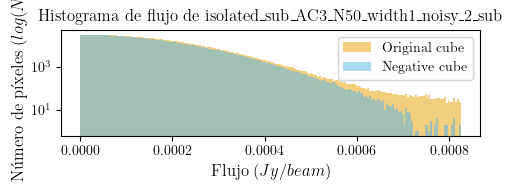

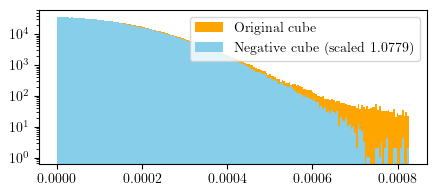

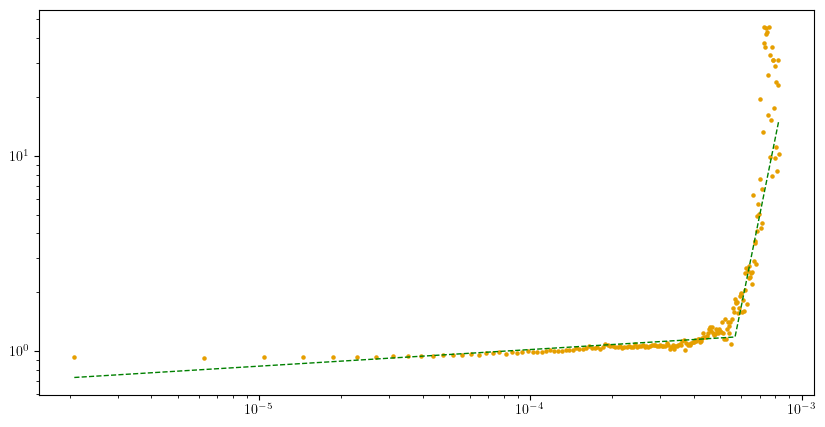

In [51]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=False)

#### 2.1.2.B Wavelets

Primer estimación: s = 1.2848 ± 0.0023   (chi2_red = 75.70)
Primer ajuste: x_break = 3.05e-04
Segunda estimación: s = 1.2808 ± 0.0023   (chi2_red = 147.38)
Segundo ajuste: x_break = 3.05e-04
x_break = 3.05e-04
B1 (zona plana) = 0.311


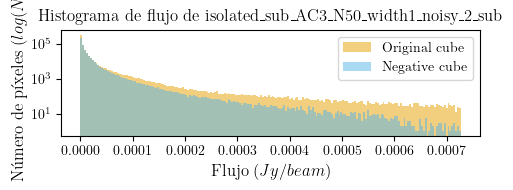

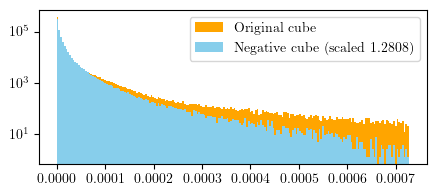

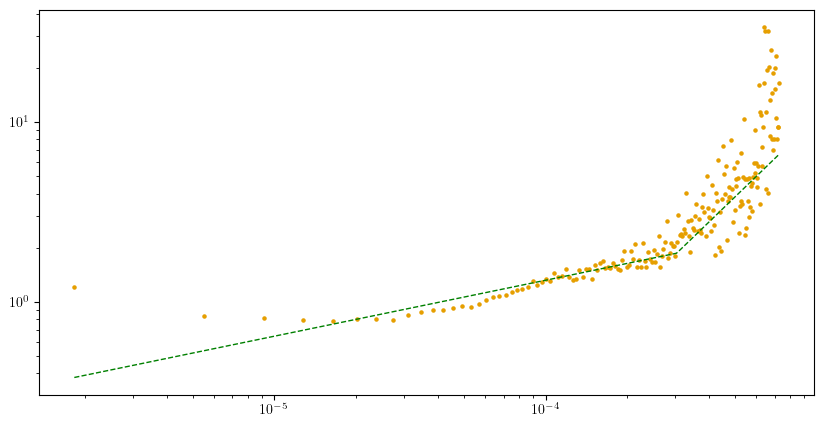

In [ ]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=5)

Primer estimación: s = 1.2222 ± 0.0020   (chi2_red = 85.00)
Primer ajuste: x_break = 3.93e-04
Segunda estimación: s = 1.2209 ± 0.0020   (chi2_red = 120.21)
Segundo ajuste: x_break = 3.93e-04
x_break = 3.93e-04
B1 (zona plana) = 0.314
Primer estimación: s = 1.0856 ± 0.0015   (chi2_red = 64.33)
Primer ajuste: x_break = 3.04e-06
Segunda estimación: s = 1.3754 ± 0.0041   (chi2_red = nan)
Segundo ajuste: x_break = 4.84e-04
x_break = 4.84e-04
B1 (zona plana) = 0.121
Primer estimación: s = 1.0354 ± 0.0012   (chi2_red = 4.28)
Primer ajuste: x_break = 5.52e-06
Segunda estimación: s = 1.0493 ± 0.0031   (chi2_red = nan)
Segundo ajuste: x_break = 7.89e-04
x_break = 7.89e-04
B1 (zona plana) = 0.012


/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_79925/595506434.py:5: RuntimeWarning: invalid value encountered in power
  A1 * (x / x_break)**B1,
/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_79925/595506434.py:6: RuntimeWarning: invalid value encountered in power
  A1 * (x / x_break)**B2


Primer estimación: s = 1.0282 ± 0.0010   (chi2_red = 9.91)
Primer ajuste: x_break = 7.28e-04
Segunda estimación: s = 1.0278 ± 0.0010   (chi2_red = 7.26)
Segundo ajuste: x_break = 7.28e-04
x_break = 7.28e-04
B1 (zona plana) = 0.002


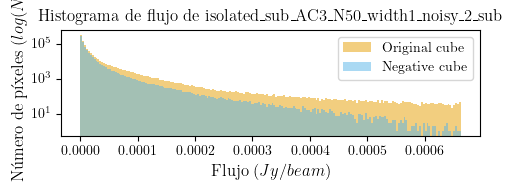

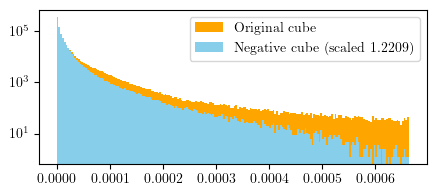

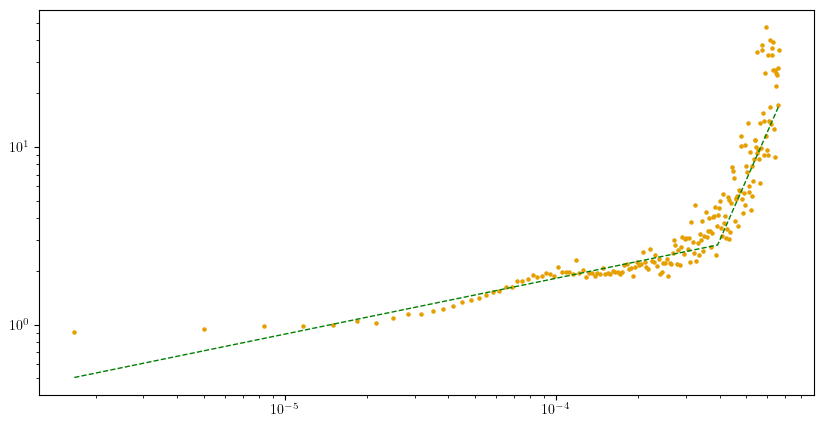

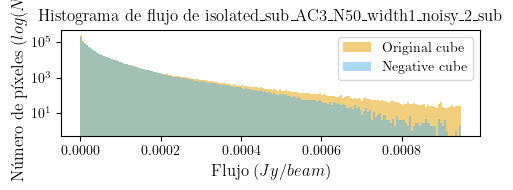

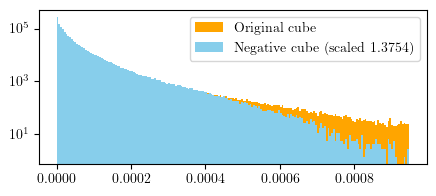

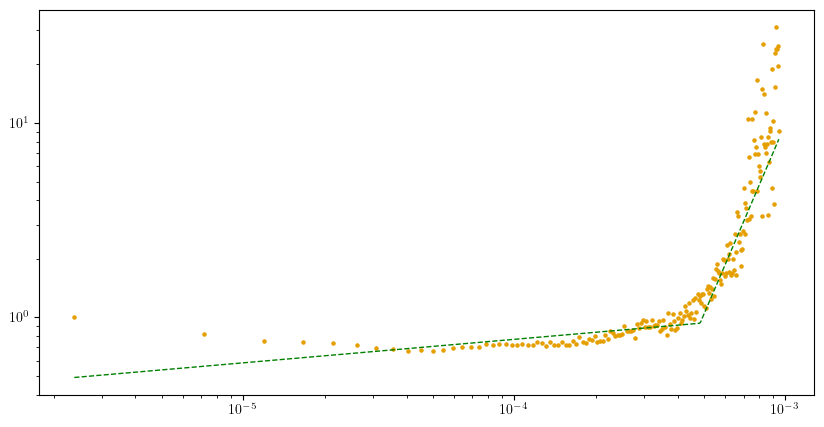

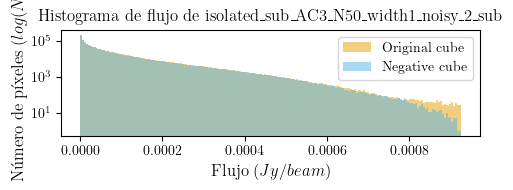

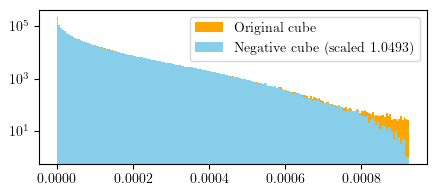

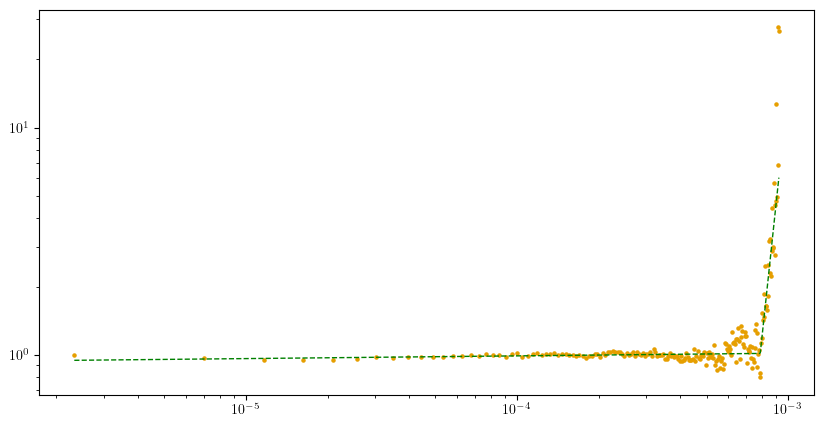

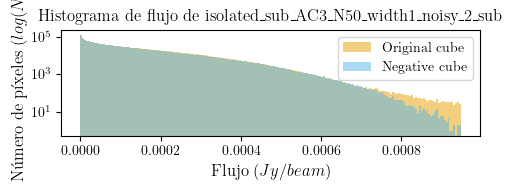

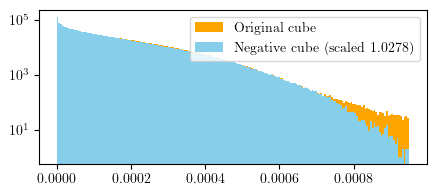

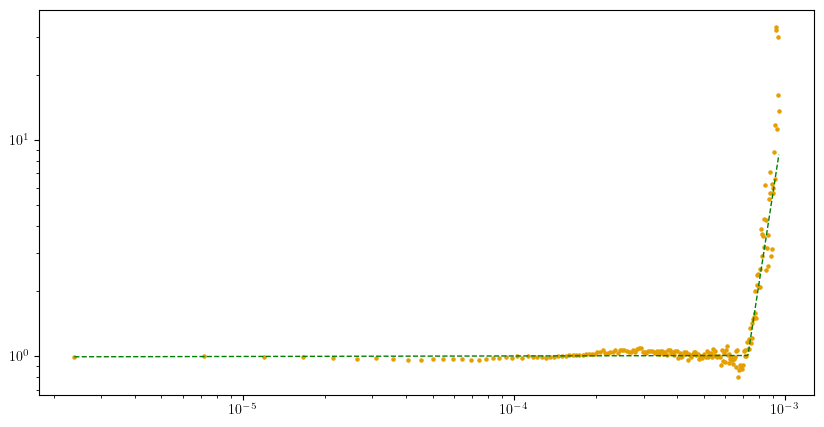

In [53]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=4)
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=3)
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=2)
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=1)

### 2.1.4. AC2

In [54]:
CUBE_DIR = 'isolated_sub_AC2_N15_width1'
CUBE_NAME = 'isolated_sub_AC2_N15_width1_noisy_sub'

#### 2.1.4.A Original Cube

Primer estimación: s = 1.0330 ± 0.0011   (chi2_red = 10.65)
Primer ajuste: x_break = 5.47e-04
Segunda estimación: s = 1.0322 ± 0.0011   (chi2_red = 8.02)
Segundo ajuste: x_break = 5.47e-04
x_break = 5.47e-04
B1 (zona plana) = 0.052


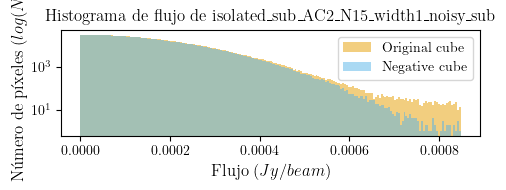

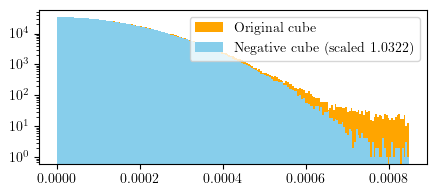

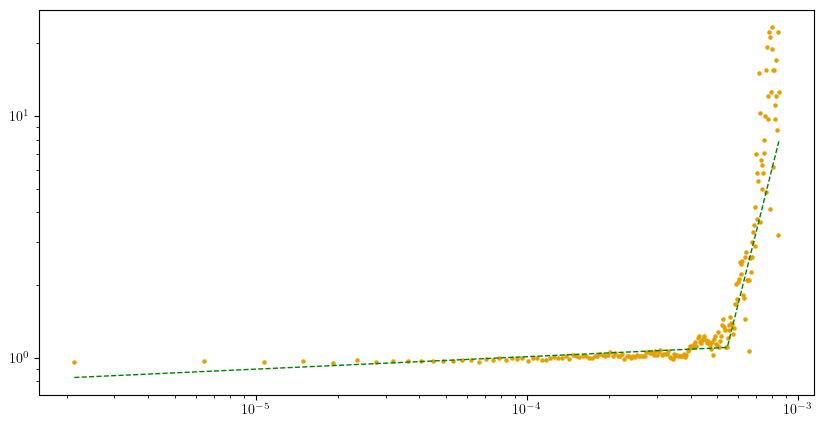

In [55]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=False)

#### 2.1.4.B Wavelets

Primer estimación: s = 1.2254 ± 0.0024   (chi2_red = 130.17)
Primer ajuste: x_break = 1.82e-05
Segunda estimación: s = 1.2071 ± 0.0026   (chi2_red = 3267.40)
Segundo ajuste: x_break = 1.82e-05
x_break = 1.82e-05
B1 (zona plana) = -0.350
Primer estimación: s = 1.0112 ± 0.0017   (chi2_red = 161.21)
Primer ajuste: x_break = 5.13e-05
Segunda estimación: s = 0.9910 ± 0.0017   (chi2_red = 1871.19)
Segundo ajuste: x_break = 1.19e-05
x_break = 1.19e-05
B1 (zona plana) = -1.589


/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_79925/595506434.py:5: RuntimeWarning: invalid value encountered in power
  A1 * (x / x_break)**B1,
/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_79925/595506434.py:6: RuntimeWarning: invalid value encountered in power
  A1 * (x / x_break)**B2


Primer estimación: s = 1.0986 ± 0.0016   (chi2_red = 69.88)
Primer ajuste: x_break = 6.26e-04
Segunda estimación: s = 1.0978 ± 0.0016   (chi2_red = 93.89)
Segundo ajuste: x_break = 6.26e-04
x_break = 6.26e-04
B1 (zona plana) = 0.212
Primer estimación: s = 1.0439 ± 0.0012   (chi2_red = 6.55)
Primer ajuste: x_break = 7.89e-04
Segunda estimación: s = 1.0436 ± 0.0012   (chi2_red = 4.65)
Segundo ajuste: x_break = 7.91e-04
x_break = 7.91e-04
B1 (zona plana) = 0.010
Primer estimación: s = 1.0116 ± 0.0010   (chi2_red = 4.18)
Primer ajuste: x_break = 7.87e-04
Segunda estimación: s = 1.0114 ± 0.0010   (chi2_red = 2.53)
Segundo ajuste: x_break = 7.87e-04
x_break = 7.87e-04
B1 (zona plana) = 0.002


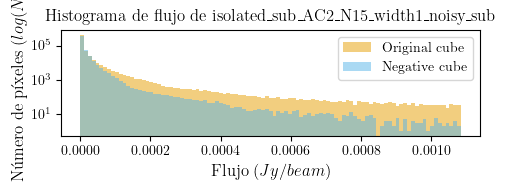

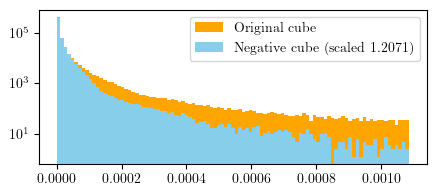

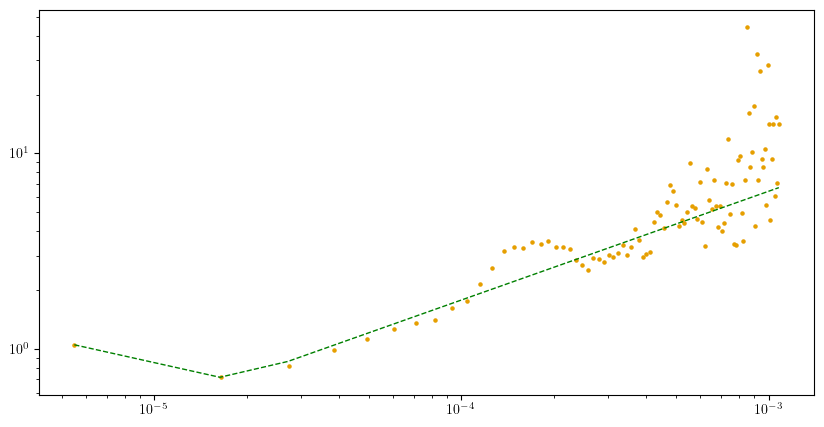

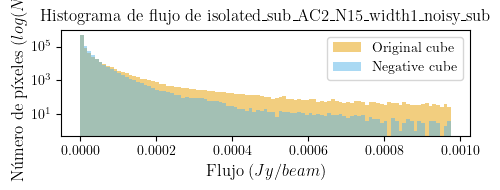

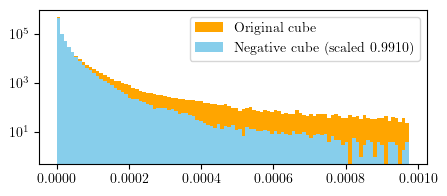

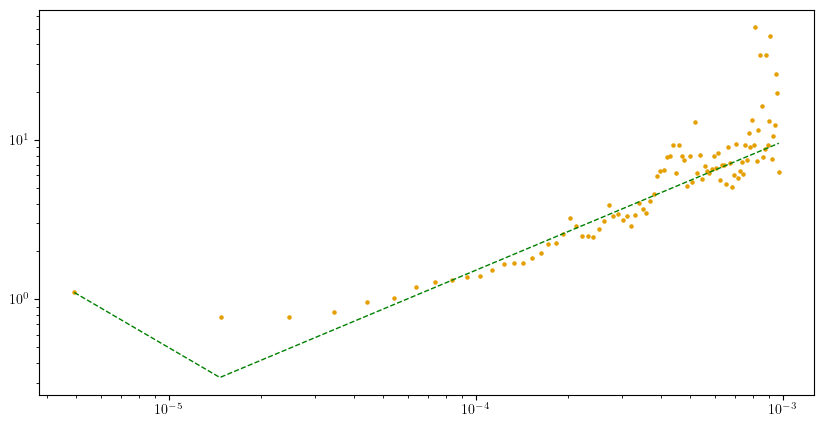

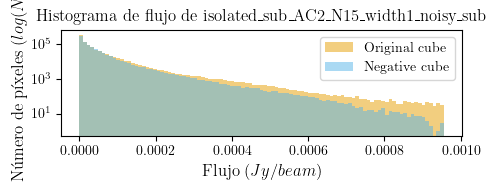

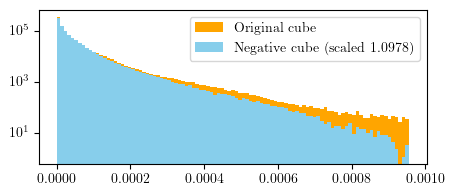

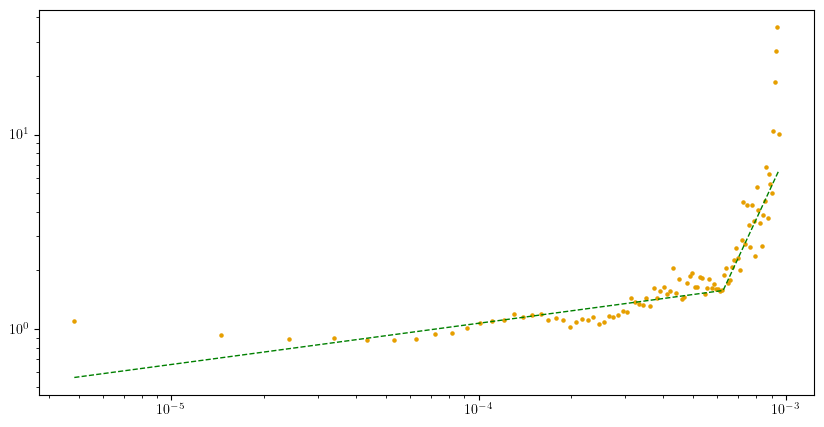

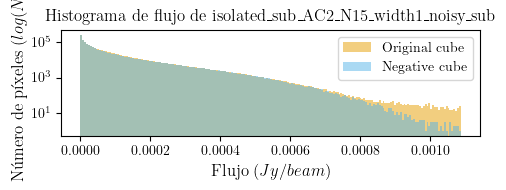

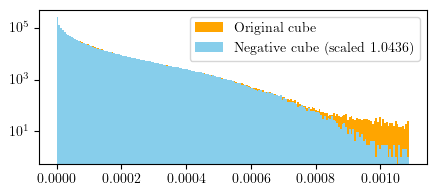

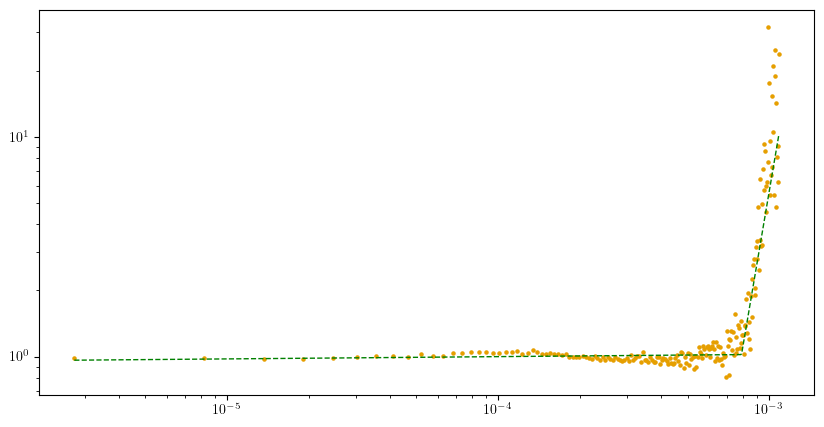

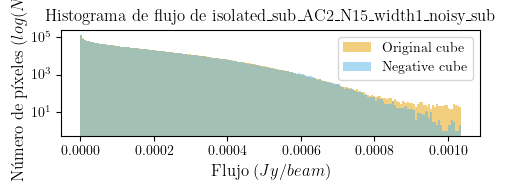

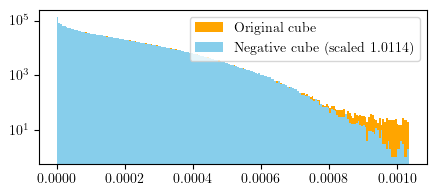

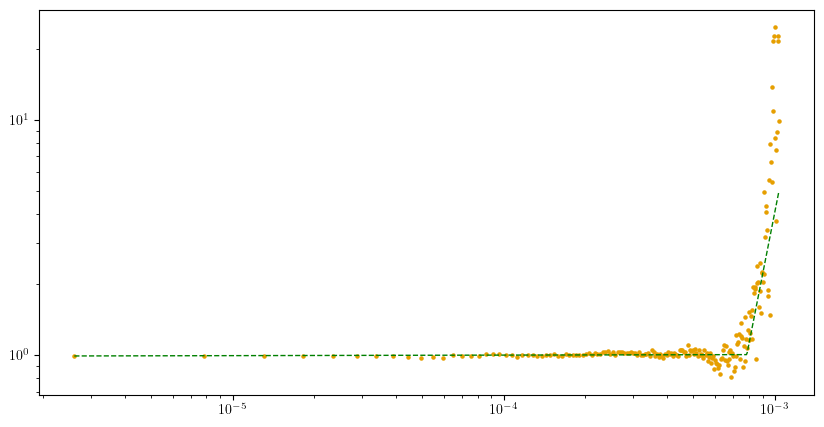

In [65]:
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=100, denoised=True, threshold=5)
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=100, denoised=True, threshold=4)
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=100, denoised=True, threshold=3)
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=2)
umbral(CUBE_NAME, CUBE_TYPE_DIR, CUBE_DIR, n_bins=200, denoised=True, threshold=1)

